# Tutorial: Understanding Quantum Device Performance with Mirror Randomized Benchmarking (MRB)

This tutorial will guide you through the process of characterizing the performance of a quantum device (or a simulation of one) using Mirror Randomized Benchmarking (MRB). We will use the `errorgnomark` library to perform the experiment, analyze the results, and visualize them in an intuitive heatmap.

### What is Mirror Randomized Benchmarking?

Randomized Benchmarking (RB) is a powerful protocol for measuring the average error rate of a set of quantum gates. The core idea is to:
1.  Apply a sequence of random gates from the Clifford group.
2.  Calculate and apply an "inverse" gate that should, in a perfect world, return the qubits to their initial state (`|00...0>`).
3.  Measure the qubits and see how often they actually return to the initial state.

The "mirror" variant (MRB) simplifies step 2. Instead of calculating a complex inverse, we simply apply the *inverse of the random sequence in reverse order*. This creates a "mirrored" circuit (`U_rand * U_rand_inverse`) that is guaranteed to be the identity operation, making it easier to implement.

By running these mirrored circuits at different lengths (depths), we can observe how the probability of returning to the correct state decays. This decay rate is directly related to the average error per gate.

In this tutorial, we will use a "direct analysis" method that computes an "effective polarization" for each experiment, providing a quick and clear picture of device performance.

In [6]:
"""
This script demonstrates how to use the direct computation method for MRB.
This updated version uses the high-level `run_direct_analysis` method, which
automatically handles running the experiment, printing a summary table, and
generating a heatmap visualization of the results.
"""

import os
import sys
import numpy as np


from errorgnomark.backends.dummy_backend import DummyBackend
from errorgnomark.experiments.benchmarking.mrb import MirrorRBExperiment

### Configuring the Experiment

All the parameters for our experiment are defined in a single `CONFIG` dictionary. This makes it easy to see and change the experimental setup.

*   `qubit_groups`: We will run four separate experiments: one on qubit 0, one on qubit 1, one on the pair (0, 1), and one on the triplet (0, 1, 2). This allows us to compare single-qubit and multi-qubit performance.
*   `depths`: We will test how performance degrades as circuits get longer.
*   `circuits_per_depth`: A single random circuit might not be representative. By averaging over 20 different random circuits at each depth, we get a statistically robust measure of the average error.
*   `shots`: We repeat each circuit 1024 times to build up statistics for the measurement outcomes.
*   `depolarizing_error`: We are telling our simulated backend that every gate should have a 0.5% chance of being replaced by a completely randomizing error.
*   `save_path`: Setting this to `None` tells the library to display the plot interactively on the screen instead of saving it to a file.

In [7]:
# ==============================================================================
# --- CONFIGURATION ---
# ==============================================================================

CONFIG = {
    # The groups of qubits on which the experiment will be run.
    "qubit_groups": [0, 1, (0, 1), (0, 1, 2)],
    
    # The circuit depths for each MRB experiment.
    "depths": [10, 50, 100, 150, 200],
    
    # The number of random circuits to generate for each depth.
    "circuits_per_depth": 20,
    
    # The number of measurement shots for each circuit.
    "shots": 1024,
    
    # The error rate for the simulated backend.
    "depolarizing_error": 0.005,
    
    # --- [MODIFIED] ---
    # To display the plot interactively, set the save_path to None.
    # To save the plot to a file, provide a filename like "my_plot.png".
    "save_path": None
}

### Running the Analysis

Now we execute the main part of the experiment. The following code will:
1.  **Set up the simulated backend** with the error rate defined in `CONFIG`.
2.  **Create the MRB experiment instance**, configured with our desired qubits, depths, and circuits per depth.
3.  **Run the complete analysis** using the high-level `run_direct_analysis` method. This single command will generate circuits, run them on the backend, process the results, print a summary table, and generate the final heatmap plot.
4.  **Print an interpretation guide** to help understand the output table and plot.


[Setup] Using DummyBackend with depolarizing error = ['depolarizing_error']

    Running MRB Direct Polarization Analysis

--- Processing group: 0 (1/4) ---
  Depth 10 (1/5): [....................] Avg S = 0.7417
  Depth 50 (2/5): [....................] Avg S = 0.2269
  Depth 100 (3/5): [....................] Avg S = 0.0552
  Depth 150 (4/5): [....................] Avg S = 0.0228
  Depth 200 (5/5): [....................] Avg S = 0.0142

--- Processing group: 1 (2/4) ---
  Depth 10 (1/5): [....................] Avg S = 0.7408
  Depth 50 (2/5): [....................] Avg S = 0.2165
  Depth 100 (3/5): [....................] Avg S = 0.0665
  Depth 150 (4/5): [....................] Avg S = 0.0180
  Depth 200 (5/5): [....................] Avg S = 0.0110

--- Processing group: (0, 1) (3/4) ---
  Depth 10 (1/5): [....................] Avg S = 0.4058
  Depth 50 (2/5): [....................] Avg S = 0.0166
  Depth 100 (3/5): [....................] Avg S = 0.0179
  Depth 150 (4/5): [............

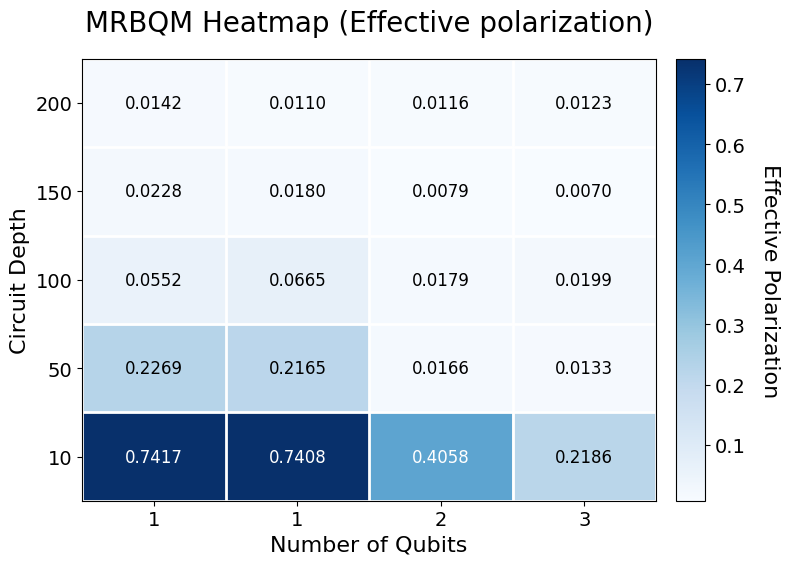


Analysis complete.


    Interpretation of Results

The summary table and the heatmap show the 'Effective Polarization (S)'.
This value is a measure of how well the quantum state survives the noisy circuit.

Key Takeaways:
  - Higher values (closer to 1.0) indicate better performance (less error).
  - Values decrease as 'Circuit Depth' increases, because longer circuits accumulate more noise.
  - Values for multi-qubit groups are typically lower than for single-qubit groups,
    reflecting the higher error rates of two-qubit gates.


In [10]:
# ==============================================================================
# --- DIRECT EXECUTION OF THE ANALYSIS ---
# ==============================================================================

# 1. Set up the simulated backend
from errorgnomark.backends.dummy_backend import DummyBackend
# Instantiate the backend with a per-gate depolarizing error and a SPAM error.
backend = DummyBackend(depolarizing_error=0.015, spam_error=0.0001)
print(f"\n[Setup] Using DummyBackend with depolarizing error = {['depolarizing_error']}\n")

# 2. Create the MRB experiment instance
# mrb_exp = MirrorRBExperiment(
#     qubits=CONFIG["qubit_groups"],
#     depths=CONFIG["depths"],
#     circuits_per_depth=CONFIG["circuits_per_depth"]
# )
mrb_exp = MirrorRBExperiment(
    qubits=CONFIG["qubit_groups"],
    depths=CONFIG["depths"],
    circuits_per_depth=CONFIG["circuits_per_depth"]
)


# 3. Run the complete analysis with a single method call.
# Because save_path is now None, this will cause the plot to be displayed.
mrb_exp.run_direct_analysis(
    backend=backend,
    shots=CONFIG["shots"],
    verbose=True,
    save_path=CONFIG["save_path"]
)

# --- Interpretation of the results ---
print("\n\n" + "=" * 60)
print("    Interpretation of Results")
print("=" * 60)
print("\nThe summary table and the heatmap show the 'Effective Polarization (S)'.")
print("This value is a measure of how well the quantum state survives the noisy circuit.")
print("\nKey Takeaways:")
print("  - Higher values (closer to 1.0) indicate better performance (less error).")
print("  - Values decrease as 'Circuit Depth' increases, because longer circuits accumulate more noise.")
print("  - Values for multi-qubit groups are typically lower than for single-qubit groups,")
print("    reflecting the higher error rates of two-qubit gates.")